<a href="https://colab.research.google.com/github/yezixx/seoul-events-subway-analysis/blob/main/%EB%8D%B0%EC%9D%B4%ED%84%B0%EB%B6%84%EC%84%9D%EB%B0%8F%ED%99%9C%EC%9A%A9_2112018_%EA%B9%80%EC%98%88%EC%A7%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 데이터셋

[서울교통공사_역별 일별 시간대별 승하차인원 정보](https://data.seoul.go.kr/dataList/OA-12921/S/1/datasetView.do)

[서울시 체육시설 공연행사 정보](https://data.seoul.go.kr/dataList/OA-15497/S/1/datasetView.do)

# 라이브러리 import

In [ ]:
!pip install -q pyod
print("PyOD 설치 완료")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.6/413.6 kB 16.8 MB/s eta 0:00:00
PyOD 설치 완료


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

plt.rcParams["figure.figsize"] = (6, 5)
plt.rcParams["axes.unicode_minus"] = False
RANDOM_STATE = 42
print("라이브러리 준비 완료")

라이브러리 준비 완료


폰트 설치

In [ ]:
!apt-get update -qq
!apt-get install -y fonts-nanum

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 39 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (88.9 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [ ]:
import matplotlib.font_manager as fm

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
font_prop = fm.FontProperties(fname=font_path)

In [ ]:
# 폰트 등록
fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(
    fname=font_path
).get_name()

print(font_name)

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

NanumGothic


# 데이터 import

In [ ]:
subway = pd.read_csv("/content/서울교통공사_역별 일별 시간대별 승하차인원_20251231.csv", encoding='cp949', on_bad_lines='skip')
event = pd.read_csv("/content/서울시 체육시설 공연행사 정보.csv", encoding='cp949')

# 서울교통공사 역별 일별 시간대별 승하차 인원 데이터

## 데이터 구조 확인

In [ ]:
subway.shape

(199424, 26)

In [ ]:
subway.head()

,연번,수송일자,호선,역번호,역명,승하차구분,06시이전,06-07시간대,07-08시간대,08-09시간대,...,15-16시간대,16-17시간대,17-18시간대,18-19시간대,19-20시간대,20-21시간대,21-22시간대,22-23시간대,23-24시간대,24시이후
0,1.0,2025-01-01,1호선,150.0,서울역,승차,411.0,317.0,419.0,733.0,...,3699.0,3694.0,3727.0,3252.0,2925.0,2210.0,2465.0,1555.0,838.0,29.0
1,2.0,2025-01-01,1호선,150.0,서울역,하차,261.0,715.0,941.0,1042.0,...,3061.0,3219.0,3128.0,2591.0,2271.0,2031.0,1553.0,945.0,455.0,130.0
2,3.0,2025-01-01,1호선,151.0,시청,승차,62.0,70.0,122.0,216.0,...,1192.0,1280.0,1276.0,1195.0,926.0,856.0,757.0,444.0,201.0,1.0
3,4.0,2025-01-01,1호선,151.0,시청,하차,70.0,271.0,296.0,479.0,...,1176.0,881.0,775.0,592.0,392.0,289.0,264.0,146.0,76.0,9.0
4,5.0,2025-01-01,1호선,152.0,종각,승차,557.0,211.0,159.0,197.0,...,1284.0,1303.0,1520.0,1490.0,1367.0,1355.0,1168.0,885.0,267.0,9.0


In [ ]:
subway.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199424 entries, 0 to 199423
Data columns (total 26 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   연번        199290 non-null  float64
 1   수송일자      199290 non-null  object 
 2   호선        199290 non-null  object 
 3   역번호       199290 non-null  float64
 4   역명        199290 non-null  object 
 5   승하차구분     199290 non-null  object 
 6   06시이전     199290 non-null  float64
 7   06-07시간대  199290 non-null  float64
 8   07-08시간대  199290 non-null  float64
 9   08-09시간대  199290 non-null  float64
 10  09-10시간대  199290 non-null  float64
 11  10-11시간대  199290 non-null  float64
 12  11-12시간대  199290 non-null  float64
 13  12-13시간대  199290 non-null  float64
 14  13-14시간대  199290 non-null  float64
 15  14-15시간대  199290 non-null  float64
 16  15-16시간대  199290 non-null  float64
 17  16-17시간대  199290 non-null  float64
 18  17-18시간대  199290 non-null  float64
 19  18-19시간대  199290 non-null  float64
 20  19-2

In [ ]:
subway.columns

Index(['연번', '수송일자', '호선', '역번호', '역명', '승하차구분', '06시이전', '06-07시간대',
       '07-08시간대', '08-09시간대', '09-10시간대', '10-11시간대', '11-12시간대', '12-13시간대',
       '13-14시간대', '14-15시간대', '15-16시간대', '16-17시간대', '17-18시간대', '18-19시간대',
       '19-20시간대', '20-21시간대', '21-22시간대', '22-23시간대', '23-24시간대', '24시이후'],
      dtype='object')

## 결측치 확인

In [ ]:
subway.isnull().sum()

,0
연번,134
수송일자,134
호선,134
역번호,134
역명,134
승하차구분,134
06시이전,134
06-07시간대,134
07-08시간대,134
08-09시간대,134


In [ ]:
subway.describe()

,연번,역번호,06시이전,06-07시간대,07-08시간대,08-09시간대,09-10시간대,10-11시간대,11-12시간대,12-13시간대,...,15-16시간대,16-17시간대,17-18시간대,18-19시간대,19-20시간대,20-21시간대,21-22시간대,22-23시간대,23-24시간대,24시이후
count,199290.000000,199290.000000,199290.000000,199290.000000,199290.000000,199290.000000,199290.000000,199290.000000,199290.000000,199290.000000,...,199290.000000,199290.000000,199290.000000,199290.000000,199290.000000,199290.000000,199290.000000,199290.000000,199290.000000,199290.000000
mean,99645.500000,1620.040293,133.526188,382.566491,933.924813,1567.039219,1054.103753,750.739520,731.690612,779.296733,...,905.986352,1041.298088,1322.861674,1640.645371,1029.343826,740.938171,675.022319,558.456982,290.963315,78.275056
std,57530.211911,1172.904255,184.553664,398.774630,1183.194486,2195.312486,1378.008033,716.267965,655.492686,687.241058,...,815.341229,945.094538,1388.416438,1927.600601,1129.515479,830.398164,802.662036,671.679351,351.230849,139.584676
min,1.000000,150.000000,0.000000,0.000000,2.000000,5.000000,0.000000,0.000000,0.000000,0.000000,...,8.000000,8.000000,2.000000,8.000000,0.000000,3.000000,2.000000,2.000000,0.000000,0.000000
25%,49823.250000,317.000000,33.000000,128.000000,220.000000,382.000000,366.000000,322.000000,321.000000,352.000000,...,406.000000,463.000000,523.000000,531.000000,344.000000,262.000000,234.000000,182.000000,87.000000,8.000000
50%,99645.500000,2528.000000,69.000000,245.000000,476.000000,863.000000,651.000000,556.000000,548.000000,596.000000,...,671.000000,773.000000,905.000000,1024.000000,674.000000,484.000000,437.000000,368.000000,191.000000,37.000000
75%,149467.750000,2641.000000,159.000000,486.000000,1171.000000,1795.000000,1188.000000,892.000000,903.000000,961.000000,...,1117.000000,1274.000000,1569.000000,1949.000000,1242.000000,880.000000,785.000000,666.000000,357.000000,102.000000
max,199290.000000,2828.000000,4310.000000,10440.000000,8757.000000,19427.000000,17248.000000,9238.000000,8989.000000,12130.000000,...,11633.000000,13109.000000,14933.000000,16029.000000,14262.000000,12124.000000,14818.000000,16500.000000,11732.000000,26951.000000


결측치 데이터 정리

In [ ]:
subway_clean = subway.dropna(subset=["수송일자"])

subway_clean.shape

(199290, 26)

In [ ]:
subway_clean.isnull().sum()

,0
연번,0
수송일자,0
호선,0
역번호,0
역명,0
승하차구분,0
06시이전,0
06-07시간대,0
07-08시간대,0
08-09시간대,0


## 데이터 값 및 컬럼 확인

In [ ]:
subway_clean["승하차구분"].unique()

array(['승차', '하차'], dtype=object)

In [ ]:
subway_clean["호선"].unique()

array(['1호선', '2호선', '3호선', '4호선', '5호선', '6호선', '7호선', '8호선'],
      dtype=object)

In [ ]:
subway_clean["역명"].nunique()

242

In [ ]:
subway_clean["수송일자"].nunique()

365

In [ ]:
subway_clean["수송일자"].head()

,수송일자
0,2025-01-01
1,2025-01-01
2,2025-01-01
3,2025-01-01
4,2025-01-01


In [ ]:
subway_clean["수송일자"].tail()

,수송일자
199285,2025-12-31
199286,2025-12-31
199287,2025-12-31
199288,2025-12-31
199289,2025-12-31


In [ ]:
subway_clean["수송일자"].isnull().sum()

np.int64(0)

날짜 범위 확인

In [ ]:
print(
  subway_clean["수송일자"].min(),
  subway_clean["수송일자"].max())

2025-01-01 2025-12-31


역명 표기 확인

In [ ]:
subway_clean["역명"].value_counts().head(20)

,count
역명,
동대문역사문화공원(DDP),2190
종로3가,2190
시청,1460
서울역,1460
동묘앞,1460
동대문,1460
신당,1460
을지로4가,1460
을지로3가,1460


일별 데이터 개수 확인

In [ ]:
subway_clean["수송일자"].value_counts().sort_index().head()

,count
수송일자,
2025-01-01,546
2025-01-02,546
2025-01-03,546
2025-01-04,546
2025-01-05,546


In [ ]:
subway_clean["수송일자"].value_counts().sort_index().tail()

,count
수송일자,
2025-12-27,546
2025-12-28,546
2025-12-29,546
2025-12-30,546
2025-12-31,546


시간대 컬럼 확인

In [ ]:
time_cols = subway_clean.columns[6:]

time_cols

Index(['06시이전', '06-07시간대', '07-08시간대', '08-09시간대', '09-10시간대', '10-11시간대',
       '11-12시간대', '12-13시간대', '13-14시간대', '14-15시간대', '15-16시간대', '16-17시간대',
       '17-18시간대', '18-19시간대', '19-20시간대', '20-21시간대', '21-22시간대', '22-23시간대',
       '23-24시간대', '24시이후'],
      dtype='object')

하루 총 이용량

In [ ]:
subway_daily = subway_clean.copy()

subway_daily["총인원"] = subway_daily[time_cols].sum(axis=1)

subway_daily[
    ["수송일자", "역명", "승하차구분", "총인원"]
].head()

,수송일자,역명,승하차구분,총인원
0,2025-01-01,서울역,승차,42041.0
1,2025-01-01,서울역,하차,35687.0
2,2025-01-01,시청,승차,11939.0
3,2025-01-01,시청,하차,11466.0
4,2025-01-01,종각,승차,15517.0


연간 총 이용객 TOP 20 역

In [ ]:
station_total = (
    subway_daily
    .groupby("역명")["총인원"]
    .sum()
    .sort_values(ascending=False)
)

station_total.head(20)

,총인원
역명,
잠실(송파구청),72717683.0
서울역,63640266.0
홍대입구,55950717.0
강남,55564369.0
사당,49465006.0
고속터미널,48250131.0
구로디지털단지,39011152.0
신림,38811319.0
종로3가,37991357.0


## 데이터 전처리

승차 + 하차 합쳐서 총 이용량 컬럼 생성

In [ ]:
subway_clean["총이용량"] = subway_clean[time_cols].sum(axis=1)

/tmp/ipykernel_590/3680202413.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subway_clean["총이용량"] = subway_clean[time_cols].sum(axis=1)


역명 표준화

In [ ]:
subway_clean["역명"] = subway_clean["역명"].str.split("(").str[0]

/tmp/ipykernel_590/1911878161.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subway_clean["역명"] = subway_clean["역명"].str.split("(").str[0]


단순 클러스터링은 의미가 약함

사람 많은 역, 중간 역, 사람 적은 역 세가지로 나눌 가능성 높음 -> 인사이트 거의 없음

역 규모 분포가 얼마나 치우쳤는지 확인

In [ ]:
subway_clean["총인원"] = subway_clean[time_cols].sum(axis=1)

subway_clean.groupby("역명")["총인원"].mean().describe()

/tmp/ipykernel_590/2767583818.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subway_clean["총인원"] = subway_clean[time_cols].sum(axis=1)


,총인원
count,241.000000
mean,16156.519947
std,12204.111219
min,1318.600000
25%,8222.032877
50%,12695.738356
75%,20707.612329
max,76644.817808


역별 시간대 프로파일 생성

In [ ]:
time_profile = (
    subway_clean
    .groupby("역명")[time_cols]
    .mean()
)

time_profile.head()

,06시이전,06-07시간대,07-08시간대,08-09시간대,09-10시간대,10-11시간대,11-12시간대,12-13시간대,13-14시간대,14-15시간대,15-16시간대,16-17시간대,17-18시간대,18-19시간대,19-20시간대,20-21시간대,21-22시간대,22-23시간대,23-24시간대,24시이후
역명,,,,,,,,,,,,,,,,,,,,
가락시장,86.015753,228.041781,504.493836,866.392466,495.828767,407.887671,411.493836,421.310959,438.591781,451.959589,499.558219,550.656849,688.186986,880.795205,502.610274,376.930822,334.624658,274.630822,143.524658,49.019178
가산디지털단지,204.550685,636.357534,2645.542466,6549.308219,3863.083562,1276.845205,1000.709589,1104.164384,1180.269863,1192.646575,1357.149315,1774.152055,3988.491781,5440.873973,2339.069863,1367.308219,1052.043836,670.568493,333.820548,77.687671
강남,328.779452,1201.794521,3209.354795,6207.065753,6277.386301,3531.012329,2984.032877,3208.598630,3726.236986,3738.232877,4058.480822,4661.079452,6609.913699,8236.090411,5305.838356,3769.504110,3856.579452,3312.289041,1581.069863,312.234247
강남구청,59.250685,333.039726,724.424658,1849.530137,1744.641096,858.564384,608.017808,610.824658,671.302740,692.516438,748.700000,847.831507,1195.745205,1736.787671,1087.290411,698.464384,617.291781,443.186301,211.587671,54.778082
강동,215.971233,532.590411,1371.047945,2019.179452,1142.897260,809.958904,758.001370,821.604110,876.575342,841.338356,909.931507,1046.956164,1339.912329,1704.949315,1064.408219,749.216438,668.824658,557.360274,319.072603,122.727397


시간대 비율화

각 역에 대해 (각 시간대 인원)/(역 전체 시간대 합)

In [ ]:
time_profile_ratio = time_profile.div(
    time_profile.sum(axis=1),
    axis=0
)

time_profile_ratio.head()

,06시이전,06-07시간대,07-08시간대,08-09시간대,09-10시간대,10-11시간대,11-12시간대,12-13시간대,13-14시간대,14-15시간대,15-16시간대,16-17시간대,17-18시간대,18-19시간대,19-20시간대,20-21시간대,21-22시간대,22-23시간대,23-24시간대,24시이후
역명,,,,,,,,,,,,,,,,,,,,
가락시장,0.009987,0.026478,0.058577,0.100596,0.057570,0.047360,0.047778,0.048918,0.050925,0.052477,0.058003,0.063937,0.079905,0.102269,0.058358,0.043765,0.038853,0.031887,0.016665,0.005692
가산디지털단지,0.005375,0.016722,0.069520,0.172103,0.101514,0.033553,0.026297,0.029015,0.031015,0.031340,0.035663,0.046621,0.104810,0.142975,0.061466,0.035930,0.027646,0.017621,0.008772,0.002041
강남,0.004319,0.015789,0.042164,0.081548,0.082472,0.046390,0.039204,0.042154,0.048955,0.049113,0.053320,0.061237,0.086840,0.108205,0.069708,0.049523,0.050667,0.043517,0.020772,0.004102
강남구청,0.003752,0.021087,0.045868,0.117105,0.110464,0.054361,0.038497,0.038675,0.042504,0.043847,0.047405,0.053681,0.075710,0.109967,0.068843,0.044224,0.039084,0.028061,0.013397,0.003468
강동,0.012084,0.029799,0.076713,0.112977,0.063947,0.045319,0.042412,0.045970,0.049046,0.047074,0.050912,0.058579,0.074971,0.095395,0.059556,0.041920,0.037422,0.031185,0.017853,0.006867


## K-means

Elbow Method로 적당한 K 선정

In [ ]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    km.fit(time_profile_ratio)

    inertia.append(km.inertia_)

print(inertia)

[0.33117770028582644, 0.2538555571287811, 0.21921638017019884, 0.1950372243156535, 0.17858555171491497, 0.16436427539124693, 0.1553157725628846, 0.14849080868614825, 0.14256242474252911]


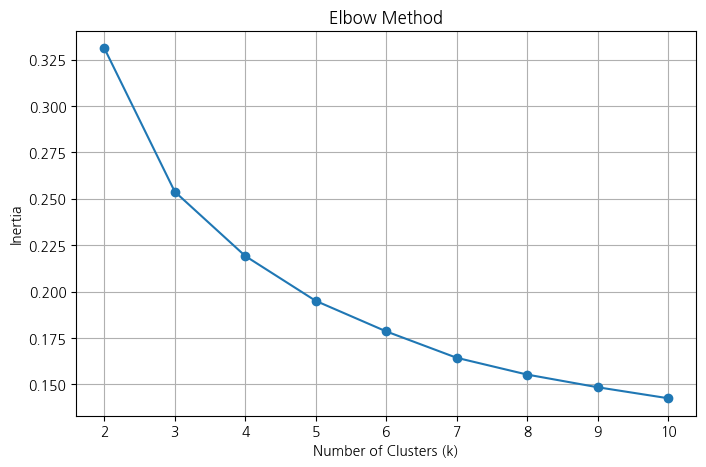

In [ ]:
import matplotlib.pyplot as plt

k_values = list(range(2, 11))

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

k=4, k=5 적절해 보임

In [ ]:
from sklearn.cluster import KMeans

# K=4
kmeans4 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster4 = kmeans4.fit_predict(time_profile_ratio)

# K=5
kmeans5 = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

cluster5 = kmeans5.fit_predict(time_profile_ratio)

result = pd.DataFrame({
    "역명": time_profile_ratio.index,
    "cluster4": cluster4,
    "cluster5": cluster5
})

print("=== K=4 ===")
print(result["cluster4"].value_counts().sort_index())

print("\n=== K=5 ===")
print(result["cluster5"].value_counts().sort_index())

=== K=4 ===
cluster4
0    122
1     20
2     43
3     56
Name: count, dtype: int64

=== K=5 ===
cluster5
0    52
1    22
2    90
3    35
4    42
Name: count, dtype: int64


클러스터 대표역 확인

In [ ]:
from scipy.spatial.distance import cdist

centers = kmeans5.cluster_centers_

for i in range(k):
    cluster_data = X[df['cluster'] == i]

    distances = cdist(
        cluster_data,
        centers[i].reshape(1,-1)
    )

    closest_idx = np.argmin(distances)

    representative_station = (
        df[df['cluster']==i]
        .iloc[closest_idx]
    )

    print(representative_station['역명'])

NameError: name 'X' is not defined

각 클러스터에 속한 역 확인 (15개만)

In [ ]:
for c in sorted(result["cluster4"].unique()):
    print(f"\n[K=4] Cluster {c}")
    print(
        result[result["cluster4"] == c]
        ["역명"]
        .head(15)
        .tolist()
    )

In [ ]:
for c in sorted(result["cluster5"].unique()):
    print(f"\n[K=5] Cluster {c}")
    print(
        result[result["cluster5"] == c]
        ["역명"]
        .head(15)
        .tolist()
    )

각 클러스터의 평균 시간대 패턴 확인

In [ ]:
cluster_profile = (
    time_profile_ratio
    .assign(cluster=cluster5)
    .groupby("cluster")
    .mean()
)

cluster_profile

In [ ]:
import matplotlib.pyplot as plt

# 시간대 순서
time_cols = cluster_profile.columns

plt.figure(figsize=(14, 6))

for cluster in cluster_profile.index:
    plt.plot(
        time_cols,
        cluster_profile.loc[cluster],
        marker='o',
        linewidth=2,
        label=f'Cluster {cluster}'
    )

plt.xticks(rotation=45)
plt.ylabel('Average Ratio')
plt.xlabel('Time Slot')
plt.title('Cluster-wise Time Distribution Pattern')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 5))

sns.heatmap(
    cluster_profile,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd"
)

plt.title("Cluster Time Profile Heatmap")
plt.xlabel("Time Slot")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

Cluster 0 / 2 → 주거형

특징
- 06~09 비율 높음
- 밤 늦게 급격히 감소

대표 역: 강동, 강일, 답십리, 남태령

Cluster 1 → 관광·환승 혼합형

대표 역: 고속터미널, 김포공항, 동대문, 올림픽공원, 이촌

특징
- 10~17시가 꾸준히 높음
- 해석
- 관광
- 공항
- 환승
- 행사

Cluster 3 → 상업·핫플형

특징
- 20~22시 비율 높음
- 22~23시 비율 높음
- 23~24시 비율 높음

대표 역: 강남, 건대입구, 성수, 명동, 상수

퇴근 후에도 사람 많음
- 상권
- 관광
- 유흥
- 데이트

Cluster 4 → 업무지구형

다른 군집보다 아침 피크가 훨씬 강함.

대표 역:가산디지털단지, 광화문, 구로디지털단지, 마곡, 마포

- 출근 집중
- 퇴근 집중
- 전형적인 오피스 지역

## 이상치 탐지

평소 패턴과 다른 날짜 탐색

(날짜, 역)별 총인원 생성

In [ ]:
daily_total = (
    subway_clean
    .groupby(["수송일자", "역명"])[time_cols]
    .sum()
)

daily_total["총인원"] = daily_total.sum(axis=1)

daily_total = daily_total.reset_index()

daily_total.head()

총인원 분포 확인

In [ ]:
daily_total["총인원"].describe()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    daily_total["총인원"],
    bins=50
)

plt.xlabel("Total passengers")
plt.ylabel("Count")
plt.title("Distribution of Daily Passengers")

plt.show()

### Z-score

In [ ]:
from scipy.stats import zscore

daily_total["zscore"] = zscore(daily_total["총인원"])

daily_total.sort_values(
    "zscore",
    ascending=False
).head(20)

잠실 원래 유동인구 많은 역이라 잠실만 나옴 -> 이상치가 아닌 원래 이런 곳

각 역별 총인원 평균과 역별 일별 총인원 비교 (평소 대비 유동인구 많은 날)

In [ ]:
daily_total["역별_zscore"] = (
    daily_total
    .groupby("역명")["총인원"]
    .transform(
        lambda x: (x - x.mean()) / x.std()
    )
)

In [ ]:
daily_total.sort_values(
    "역별_zscore",
    ascending=False
)[["수송일자","역명","총인원","역별_zscore"]].head(30)

**남태령 2025-03-25**
- 13530명
- z = 12.66

남태령은 평소 이용객이 적은 역이라 평소보다 엄청난 증가가 있었던 것.

행사, 집회, 특정 이벤트, 데이터 오류 중 하나일 가능성이 있음.


**여의나루 2025-09-27**
- 112903명
- z = 9.27

불꽃축제있는 날짜로 추정됨

**월드컵경기장**
- 2025-07-31
- 2025-08-03
- 2025-09-14
- 2025-10-10

반복 등장

축구 경기나 대형 공연 가능성 높음.

**명동 12/25**
- 137259명

크리스마스

**이태원 10/31**
- 48333명

할로윈 시즌.

특정 이상치 의심 날짜 vs 평상시 비교

e.g. 여의나루 2025-09-27


In [ ]:
station = "여의나루"
target_date = "2025-09-27"

평균 패턴

In [ ]:
normal = (
    subway_clean[subway_clean["역명"] == station]
    .groupby("수송일자")[time_cols]
    .sum()
    .mean()
)

이상치 의심 날짜

In [ ]:
abnormal = (
    subway_clean[
        (subway_clean["역명"] == station)
        &
        (subway_clean["수송일자"] == target_date)
    ][time_cols]
    .sum()
)

시각화

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(time_cols, normal, label="평균")
plt.plot(time_cols, abnormal, label=target_date)

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.show()

19~21시가 0 -> 해당 날짜 데이터에 일부 결측 또는 집계 오류 예상

또는 유동인구 증가로 인한 안전상의 이유로 지하철 무정차 통과 시행했을 가능성 있음 -> 실제로 무정차 통과
- https://www.joongang.co.kr/article/25370477
- https://news.kbs.co.kr/news/pc/view/view.do?ncd=8369430&ref=A
- 대략 18시~21시에 무정차 통과

In [ ]:
daily_pattern = (
    subway_clean
    .groupby(["수송일자", "역명"])[time_cols]
    .sum()
)

daily_pattern.shape

In [ ]:
daily_pattern.isna().sum().sum()

### LOF

시간대별 승하차 수는 규모 차이가 크므로 표준화

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(daily_pattern)

LOF 실행

In [ ]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.01
)

pred = lof.fit_predict(X_scaled)

lof_score = -lof.negative_outlier_factor_

결과 테이블 생성

In [ ]:
lof_result = daily_pattern.reset_index()

lof_result["lof_score"] = lof_score
lof_result["anomaly"] = pred

lof_result.head()

이상치 상위 30개 확인

In [ ]:
lof_result.sort_values(
    "lof_score",
    ascending=False
)[["수송일자", "역명", "lof_score"]].head(30)

In [ ]:
top20 = lof_result.sort_values(
    "lof_score",
    ascending=False
).head(20)

plt.figure(figsize=(12,6))

plt.barh(
    top20["역명"] + " (" + top20["수송일자"].astype(str) + ")",
    top20["lof_score"]
)

plt.xlabel("LOF Score")
plt.ylabel("Station-Date")
plt.title("Top 20 LOF Outliers")

plt.gca().invert_yaxis()
plt.show()

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    lof_result["lof_score"],
    bins=50
)

plt.xlabel("LOF Score")
plt.ylabel("Count")
plt.title("Distribution of LOF Scores")

plt.show()

이상치가 적어서 잘 안 보임 -> 로그 스케일 변환

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    lof_result["lof_score"],
    bins=100
)

plt.yscale("log")

plt.xlabel("LOF Score")
plt.ylabel("Count (log scale)")
plt.title("Distribution of LOF Scores")

plt.show()

LOF 점수 분포를 로그 스케일로 시각화한 결과 대부분의 데이터가 1~2 구간에 집중되어 있었으며, 점수가 증가할수록 데이터 수가 급격히 감소하는 장꼬리(Long Tail) 형태를 보였다. 이는 서울 지하철 이용 패턴이 전반적으로 매우 안정적이며, 일부 소수의 관측치만이 평상시와 다른 이용 패턴을 보인다는 것을 의미한다. 특히 LOF 5 이상 구간은 극히 드물게 나타났으며, 해당 데이터들은 공휴일, 연말 행사, 대규모 공연 및 스포츠 경기 등의 영향으로 발생한 이상 이용 패턴으로 해석할 수 있다.

이상치 상위 20개 LOF 점수 시각화

In [ ]:
top20 = lof_result.nlargest(20, "lof_score").copy()

top20["label"] = (
    top20["역명"] + "\n" +
    top20["수송일자"].astype(str)
)

plt.figure(figsize=(12,6))

plt.bar(
    top20["label"],
    top20["lof_score"]
)

plt.xticks(rotation=70)
plt.ylabel("LOF Score")
plt.xlabel("Station / Date")
plt.title("Top 20 LOF Anomalies")

plt.tight_layout()
plt.show()

### DBSCAN

현재 데이터가 X_scaled.shape = (87600, 20)

DBSCAN은 내부적으로 이웃 탐색을 엄청 많이 하는 알고리즘이라 런타임 다운될 수 있음 -> PCA 수행하여 차원 축소

In [ ]:
X_scaled

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=5)

X_pca = pca.fit_transform(X_scaled)

설명력 확인

In [ ]:
print(
    pca.explained_variance_ratio_.sum()
)

In [ ]:
from sklearn.cluster import DBSCAN

db = DBSCAN(
    eps=2,
    min_samples=10
)

labels = db.fit_predict(X_pca)

In [ ]:
pd.Series(labels).value_counts().sort_index()

대다수 패턴 -Cluster 0

특정 패턴 - Cluster 1

어디에도 속하지 않는 극단 패턴 - -1

이상치 85개 확인

In [ ]:
dbscan_result = daily_pattern.reset_index().copy()

dbscan_result["cluster"] = labels

dbscan_result[
    dbscan_result["cluster"] == -1
][["수송일자","역명"]]

이상치 발생 날짜 count

In [ ]:
outlier_df = dbscan_result[
    dbscan_result["cluster"] == -1
].copy()

In [ ]:
outlier_df["수송일자"].value_counts().head(20)

2025-12-31일에 이상치 가장 많음 -> 해당 날짜만 자세히 보기

In [ ]:
top_date = (
    outlier_df["수송일자"]
    .value_counts()
    .idxmax()
)

print(top_date)

In [ ]:
outlier_df[
    outlier_df["수송일자"] == top_date
][["역명"]]

상위 역 확인

In [ ]:
dbscan_result[
    dbscan_result["cluster"] == -1
]["역명"].value_counts().head(20)

**DBSCAN이 잡은 이상치의 특징**

상위 역들을 보면

잠실- 야구장, 콘서트, 롯데월드

홍대입구 - 축제, 연말, 주말

서울역 - 명절, 연휴

강남 - 연말, 쇼핑, 약속

월드컵경기장 - 공연, 경기

종로3가 - 종각·광화문 연말 인파 영향

이태원 - 핼러윈, 주말

명동 - 관광객

LOF와 겹치는지 확인

In [ ]:
lof_top = set(
    lof_result
    .sort_values("lof_score", ascending=False)
    .head(100)
    .index
)

dbscan_outlier = set(
    dbscan_result[
        dbscan_result["cluster"] == -1
    ].index
)

len(lof_top & dbscan_outlier)

PCA 시각화

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_vis = pca.fit_transform(X_scaled)

In [ ]:
plt.figure(figsize=(10,8))

plt.scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=labels,
    s=5
)

plt.title("DBSCAN Result")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

### LOF, DBSCAN 교집합 추출

In [ ]:
lof_top = set(
    lof_result
    .sort_values("lof_score", ascending=False)
    .head(300)
    .index
)

dbscan_outlier = set(
    dbscan_result[
        dbscan_result["cluster"] == -1
    ].index
)

common = lof_top & dbscan_outlier

common_df = daily_pattern.reset_index().loc[list(common)]

common_df[
    ["수송일자", "역명"]
].sort_values("수송일자")

In [ ]:
common_df["수송일자"].value_counts()

In [ ]:
common_df["역명"].value_counts()

In [ ]:
common_df["수송일자"].sort_values().unique()

**LOF(Local Outlier Factor) 분석 결과**

* 시간대별 이용객 수를 비율로 변환한 후 LOF를 적용하여 평소와 다른 이용 패턴을 보이는 역-날짜 조합을 탐지하였다.

* 분석 결과 잠실, 홍대입구, 동대문역사문화공원, 월드컵경기장, 한강진, 안국, 종합운동장 등이 높은 이상치 점수를 기록하였다.

* 이들 역은 출퇴근 수요 중심의 일반적인 역과 달리 공연, 축제, 관광, 스포츠 경기, 연휴 등의 영향을 크게 받는 역으로 나타났다.

* 이상치로 탐지된 날짜는 주로 신정(1월 1일), 설 연휴(1월 29\~31일), 삼일절(3월 1일), 핼러윈 시기(10월 31일), 연말(12월 24\~31일) 등에 집중되었다.

* 이는 특정 이벤트 발생 시 평소 출퇴근 중심 패턴과 다른 이동 수요가 발생함을 의미한다.

* 특히 잠실, 월드컵경기장, 동대문역사문화공원 등은 대규모 행사 및 문화 활동이 집중되는 지역으로, 시간대별 이용 패턴 변화가 크게 나타나는 특징을 보였다.

* LOF 분석을 통해 서울 지하철 이용 패턴은 단순한 통근·통학 수요뿐 아니라 공휴일, 관광, 대규모 행사 등의 외부 요인에 의해 크게 변화한다는 점을 확인할 수 있었다.

**DBSCAN 분석 결과**

* PCA를 이용해 시간대별 이용 패턴을 저차원 공간으로 축소한 뒤 DBSCAN을 적용하였다.

* 전체 87,600개의 역-일 데이터 중 85개만 이상치로 분류되어 대부분의 지하철 이용 패턴은 매우 안정적인 군집을 형성하는 것으로 나타났다.

* 이상치 역으로는 잠실, 홍대입구, 서울역, 강남, 월드컵경기장, 사당, 종로3가, 광화문, 이태원 등이 주로 탐지되었다.

* 이상치 발생 날짜는 특정 시기에 집중되는 경향을 보였다.

  * 2025-12-31 : 33건
  * 2025-12-24 : 4건
  * 2025-03-01 : 4건
  * 2025-12-19 : 3건
  * 2025-11-01 : 3건
  * 2025-12-25 : 3건
  * 2025-12-26 : 3건

* 특히 전체 이상치의 약 39%가 2025년 12월 31일에 집중되어 연말 이동 패턴이 서울 지하철에서 가장 특이한 이용 형태임을 확인할 수 있었다.

* 설 연휴, 삼일절, 크리스마스, 연말과 같이 대규모 이동 수요가 발생하는 시기에 이상치가 반복적으로 탐지되었다.

* 이는 평상시의 출퇴근 패턴과 달리 특정 시간대에 이용객이 집중되는 이벤트성 이동이 발생했기 때문으로 해석할 수 있다.

**LOF와 DBSCAN 비교**

* LOF와 DBSCAN 결과를 비교한 결과 23개의 역-날짜 조합이 두 알고리즘에서 동시에 이상치로 탐지되었다.

* 공통 이상치가 발생한 날짜는 다음과 같다.

  * 2025-01-01
  * 2025-01-29 ~ 2025-01-31
  * 2025-03-01
  * 2025-04-11
  * 2025-04-26
  * 2025-09-27
  * 2025-10-10
  * 2025-10-31
  * 2025-11-01 ~ 2025-11-02
  * 2025-12-12
  * 2025-12-19
  * 2025-12-24 ~ 2025-12-25
  * 2025-12-31

* 공통 이상치는 연휴, 공휴일, 축제, 연말과 같은 특별한 사회·문화적 이벤트가 발생한 시기에 집중되었다.

* 따라서 서울 지하철의 이상 이용 패턴은 단순히 이용객 수 증가 때문이 아니라 특정 이벤트로 인해 시간대별 이동 구조 자체가 변화하면서 발생하는 것으로 해석할 수 있다.


# 서울시 체육시설 공연행사 정보 데이터

## 데이터 구조 및 값 확인

In [ ]:
event.shape

In [ ]:
event.head()

In [ ]:
event.info()

In [ ]:
event.columns

결측치 확인

In [ ]:
event.isnull().sum()

In [ ]:
event.describe()

데이터 값 종류 확인

In [ ]:
event["분야명"].value_counts()

In [ ]:
event["시설명"].nunique()

In [ ]:
event["시설명"].value_counts().head(10)

날짜 범위 확인

In [ ]:
print(
    event["시작일"].min(),
    event["종료일"].max()
)

행사 시작일 분포 확인

In [ ]:
event["시작일"].astype(str).str[:4].value_counts().sort_index()

시작일, 종료일 확인

In [ ]:
event[["시작일", "종료일"]].head(10)

행사공연 기간이 하루인 데이터 값 개수

True -> 하루

False -> 2일 이상

In [ ]:
(event["시작일"] == event["종료일"]).value_counts()

시설명 확인

In [ ]:
event["시설명"].value_counts()

## 데이터 전처리

행사 데이터에서 2025년 행사 개수 확인

In [ ]:
event["시작연도"] = event["시작일"].astype(str).str[:4]

event["시작연도"].value_counts().sort_index()

날짜형으로 변환

e.g. 20260612 -> 2026-06-12

In [ ]:
event["시작일"] = pd.to_datetime(
    event["시작일"],
    format="%Y%m%d"
)

event["종료일"] = pd.to_datetime(
    event["종료일"],
    format="%Y%m%d"
)

event[["시작일", "종료일"]].head()

2025년과 겹치는 행사 확인

시작일: 2024-12-30
종료일: 2025-01-03 같이 기간이 전년도와 겹치는 데이터 확인하기 위함

In [ ]:
event_2025 = event[
    (event["종료일"] >= "2025-01-01") &
    (event["시작일"] <= "2025-12-31")
]

event_2025.shape

2025 행사 시설 분포 보기

In [ ]:
event_2025["시설명"].value_counts()

시설에서 가까운 지하철 역 리스트
- 도메인 지식 활용하여 직접 작성

In [ ]:
facility_station = {
    "잠실야구장": "종합운동장",
    "잠실실내체육관": "종합운동장",
    "잠실종합운동장": "종합운동장",

    "목동야구장": "오목교(목동운동장앞)",
    "목동주경기장": "오목교(목동운동장앞)",
    "목동실내빙상장": "오목교(목동운동장앞)",

    "구의야구공원": "구의(광진구청)",

    "신월야구공원": "까치산"   # 일단 후보
}